In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

def format_ticks(value, _):
    if value >= 1e6:
        return f'{int(value / 1e6)}m'
    elif value >= 1e3:
        return f'{int(value / 1e3)}k'
    else:
        return str(int(value))

def parse_log_file(file_path, method):
    """
    file_path: str
    method: "jolt" | "nexus" | "sp1" | "ceno"
    """
    with open(file_path, 'r') as file:
        content = file.read()

    if method == 'jolt':
        proof_duration_match = re.search(r'proof generation took:\s*([\d.]+)(ms|s)', content)
        max_memory_match = re.search(r'Maximum resident set size \(kbytes\):\s*(\d+)', content)
        user_cycles_match = re.search(r'trace len:\s*(\d+)', content)
        if proof_duration_match:
            proof_duration_value = float(proof_duration_match.group(1))
            proof_duration_unit = proof_duration_match.group(2)
            proof_duration_sec = (
                proof_duration_value / 1000 if proof_duration_unit == 'ms' else proof_duration_value
            )
        else:
            proof_duration_sec = None
    if method == 'nexus':
        proof_duration_match = re.search(r'User time \(seconds\):\s*([\d.]+)', content)
        max_memory_match = re.search(r'Maximum resident set size \(kbytes\):\s*(\d+)', content)    
        proof_duration_sec = float(proof_duration_match.group(1)) if proof_duration_match else None
        user_cycles_match = None
    if method == "sp1":
        proof_duration_match = re.search(r'proof generation took:\s*([\d.]+)(ms|s)', content)
        max_memory_match = re.search(r'Maximum resident set size \(kbytes\):\s*(\d+)', content)
        user_cycles_match = re.search(r'executed program with (\d+) cycles', content)
        if proof_duration_match:
            proof_duration_value = float(proof_duration_match.group(1))
            proof_duration_unit = proof_duration_match.group(2)
            proof_duration_sec = (
                proof_duration_value / 1000 if proof_duration_unit == 'ms' else proof_duration_value
            )
        else:
            proof_duration_sec = None


    max_memory_kb = int(max_memory_match.group(1)) if max_memory_match else None
    user_cycles = int(user_cycles_match.group(1)) if user_cycles_match else None

    return {
        'file': os.path.basename(file_path),
        'proof_duration_sec': proof_duration_sec,
        'max_memory': max_memory_kb,
        'user_cycles': user_cycles
    }

def parse_ceno_log_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()

    proof_matches = re.findall(
        r'::create_proof, max_steps = (\d+), time = ([\d.]+), peak_memory = (\d+)', 
        content
    )

    data = []
    for match in proof_matches:
        max_steps = int(match[0])
        time_sec = float(match[1])
        peak_memory = int(match[2])
        data.append({
            'user_cycles': max_steps,  # cycles = max_steps
            'proof_duration_sec': time_sec,
            'max_memory': peak_memory,
        })
    
    df = pd.DataFrame(data)
    grouped_df = df.groupby('user_cycles').mean().reset_index()
    return grouped_df

def parse_multiple_logs(files, method):
    data = []
    for file_name in files:
        file_path = os.path.basename(file_name)
        parsed_data = parse_log_file(file_path, method)
        data.append(parsed_data)
    return pd.DataFrame(data)

# Load SP1 CSV Files
sp1_fib_log_files = [
    "sp1_fibonacci_n10.log",
    "sp1_fibonacci_n100.log", 
    "sp1_fibonacci_n1000.log",
    "sp1_fibonacci_n10000.log", 
    "sp1_fibonacci_n100000.log",
    "sp1_fibonacci_n1000000.log",
    "sp1_fibonacci_n2000000.log",
    "sp1_fibonacci_n3000000.log",
    "sp1_fibonacci_n4000000.log",
    "sp1_fibonacci_n5000000.log",
]
sp1_fib_df = parse_multiple_logs(sp1_fib_log_files, 'sp1')
sp1_matrix_log_files = ["sp1_matrix-ops_n10.log", "sp1_matrix-ops_n20.log", 
             "sp1_matrix-ops_n30.log", "sp1_matrix-ops_n40.log", "sp1_matrix-ops_n50.log"]
sp1_matrix_df = parse_multiple_logs(sp1_matrix_log_files, 'sp1')

# Load RISC0 CSV Files
risc0_fib_csv_file_name = 'RISC0_fibonacci_metrics.csv'
risc0_fib_df = pd.read_csv(risc0_fib_csv_file_name)
risc0_fib_df['proof_duration_sec'] = risc0_fib_df['proof_duration'] / 1e9
risc0_matrix_csv_file_name = 'RISC0_matrix_ops_metrics.csv'
risc0_matrix_df = pd.read_csv(risc0_matrix_csv_file_name)
risc0_matrix_df['proof_duration_sec'] = risc0_fib_df['proof_duration'] / 1e9

# Load Jolt CSV Files
jolt_fib_log_files = [
    "jolt_fibonacci_n10.log",
    "jolt_fibonacci_n100.log", 
    "jolt_fibonacci_n1000.log",
    "jolt_fibonacci_n10000.log", 
    "jolt_fibonacci_n100000.log",
    "jolt_fibonacci_n110000.log",
    "jolt_fibonacci_n120000.log",
    "jolt_fibonacci_n130000.log",
    "jolt_fibonacci_n140000.log",
]
jolt_fib_df = parse_multiple_logs(jolt_fib_log_files, 'jolt')
jolt_matrix_log_files = ["jolt_matrix_ops_n10.log", "jolt_matrix_ops_n20.log", 
             "jolt_matrix_ops_n30.log", "jolt_matrix_ops_n40.log"]
jolt_matrix_df = parse_multiple_logs(jolt_matrix_log_files, 'jolt')

# Load Nexus CSV Files
nexus_fib_log_files = ["nexus_fibonacci_n10.log", "nexus_fibonacci_n100.log", 
             "nexus_fibonacci_n1000.log", "nexus_fibonacci_n10000.log", 
             "nexus_fibonacci_n100000.log", "nexus_fibonacci_n1000000.log"]
nexus_fib_df = parse_multiple_logs(nexus_fib_log_files, 'nexus')
nexus_matrix_df = nexus_fib_df.copy()
nexus_matrix_df['proof_duration_sec'] = 70000
nexus_matrix_df['max_memory'] = 5044752


# Load Ceno CSV Files
ceno_fib_csv_file_name = 'ceno_fibonacci.log'
ceno_fib_df = parse_ceno_log_file(os.path.basename(ceno_fib_csv_file_name))


/var/folders/61/n97p1zy55y3gsdfcwt02vmkh0000gp/T/ipykernel_15432/3025727155.py:14: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  axes[0].set_ylim(0, 100000)
/var/folders/61/n97p1zy55y3gsdfcwt02vmkh0000gp/T/ipykernel_15432/3025727155.py:29: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  axes[1].set_ylim(0, 100000)


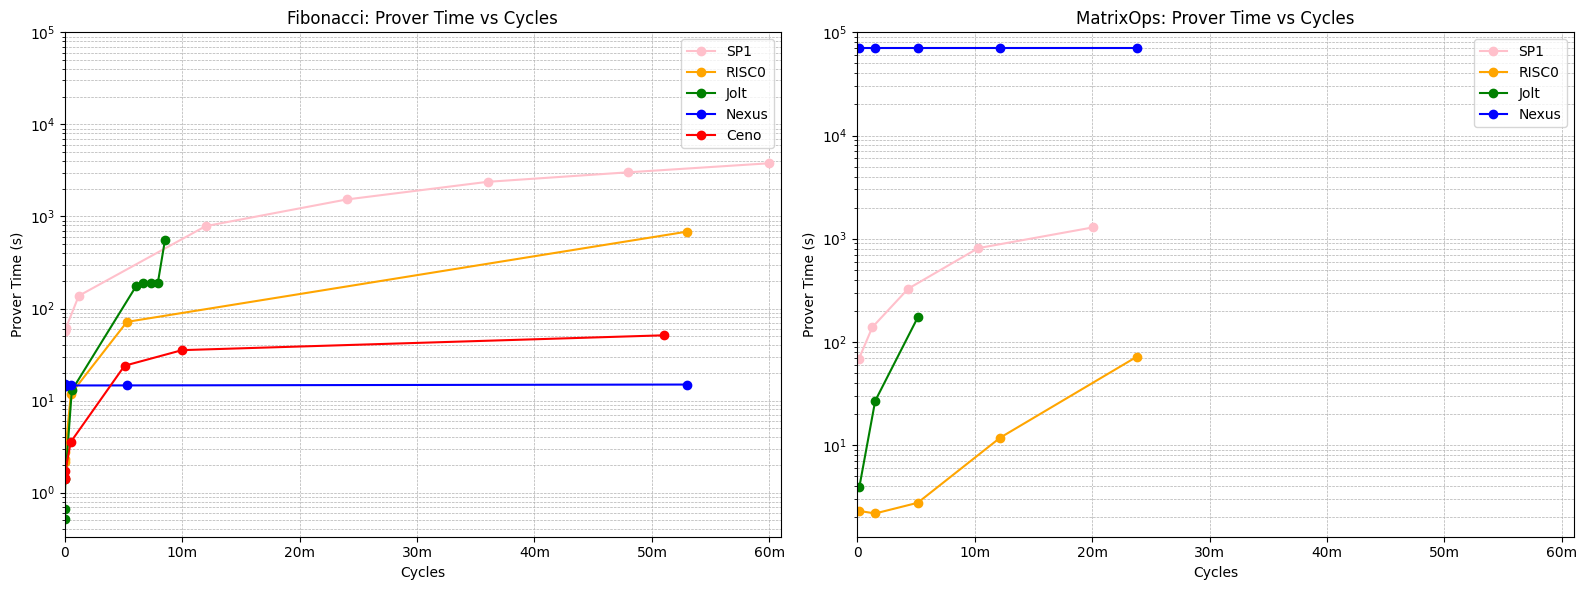

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fibonacci Prover Time vs Cycles
axes[0].plot(sp1_fib_df['user_cycles'], sp1_fib_df['proof_duration_sec'], marker='o', label='SP1', color='pink')
axes[0].plot(risc0_fib_df['user_cycles'], risc0_fib_df['proof_duration_sec'], marker='o', label='RISC0', color='orange')
axes[0].plot(jolt_fib_df['user_cycles'], jolt_fib_df['proof_duration_sec'], marker='o', label='Jolt', color='green')
axes[0].plot(risc0_fib_df['user_cycles'], nexus_fib_df['proof_duration_sec'], marker='o', label='Nexus', color='blue')
axes[0].plot(ceno_fib_df['user_cycles'], ceno_fib_df['proof_duration_sec'], marker='o', label='Ceno', color='red')
axes[0].set_title('Fibonacci: Prover Time vs Cycles')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Prover Time (s)')
axes[0].set_yscale('log')
axes[0].set_xlim(0, 61000000)
axes[0].set_ylim(0, 100000)
axes[0].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend()

# MatrixOps Prover Time vs Cycles
axes[1].plot(sp1_matrix_df['user_cycles'], sp1_matrix_df['proof_duration_sec'], marker='o', label='SP1', color='pink')
axes[1].plot(risc0_matrix_df['user_cycles'], risc0_matrix_df['proof_duration_sec'], marker='o', label='RISC0', color='orange')
axes[1].plot(jolt_matrix_df['user_cycles'], jolt_matrix_df['proof_duration_sec'], marker='o', label='Jolt', color='green')
axes[1].plot(risc0_matrix_df['user_cycles'], nexus_matrix_df['proof_duration_sec'][:-1], marker='o', label='Nexus', color='blue')
axes[1].set_title('MatrixOps: Prover Time vs Cycles')
axes[1].set_xlabel('Cycles')
axes[1].set_ylabel('Prover Time (s)')
axes[1].set_yscale('log')
axes[1].set_xlim(0, 61000000)
axes[1].set_ylim(0, 100000)
axes[1].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/61/n97p1zy55y3gsdfcwt02vmkh0000gp/T/ipykernel_15432/379047682.py:14: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  axes[0].set_ylim(0, 50)
/var/folders/61/n97p1zy55y3gsdfcwt02vmkh0000gp/T/ipykernel_15432/379047682.py:29: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  axes[1].set_ylim(0, 50)


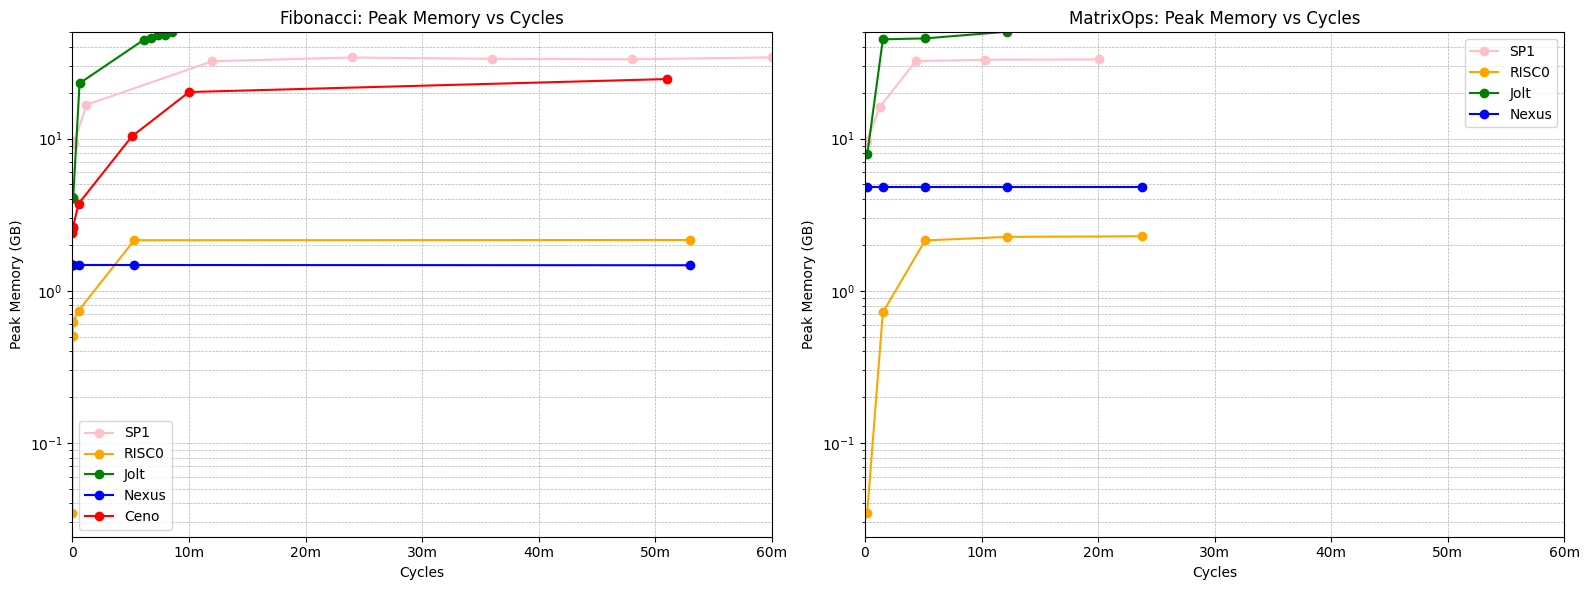

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fibonacci Peak Memory vs Cycles
axes[0].plot(sp1_fib_df['user_cycles'], sp1_fib_df['max_memory'] / 1024 / 1024, marker='o', label='SP1', color='pink')
axes[0].plot(risc0_fib_df['user_cycles'], risc0_fib_df['max_memory'] / 1024 / 1024 / 1024, marker='o', label='RISC0', color='orange')
axes[0].plot(jolt_fib_df['user_cycles'], jolt_fib_df['max_memory'] / 1024 / 1024, marker='o', label='Jolt', color='green')
axes[0].plot(risc0_fib_df['user_cycles'], nexus_fib_df['max_memory'] / 1024 / 1024, marker='o', label='Nexus', color='blue')
axes[0].plot(ceno_fib_df['user_cycles'], ceno_fib_df['max_memory'] / 1024 / 1024 / 1024, marker='o', label='Ceno', color='red')
axes[0].set_title('Fibonacci: Peak Memory vs Cycles')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Peak Memory (GB)')
axes[0].set_yscale('log')
axes[0].set_xlim(0, 60000000)
axes[0].set_ylim(0, 50)
axes[0].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend()

# MatrixOps Peak Memory vs Cycles
axes[1].plot(sp1_matrix_df['user_cycles'], sp1_matrix_df['max_memory'] / 1024 / 1024, marker='o', label='SP1', color='pink')
axes[1].plot(risc0_matrix_df['user_cycles'], risc0_matrix_df['max_memory'] / 1024 / 1024 / 1024, marker='o', label='RISC0', color='orange')
axes[1].plot(jolt_matrix_df['user_cycles'], jolt_matrix_df['max_memory'] / 1024 / 1024, marker='o', label='Jolt', color='green')
axes[1].plot(risc0_matrix_df['user_cycles'], nexus_matrix_df['max_memory'][:-1] / 1024 / 1024, marker='o', label='Nexus', color='blue')
axes[1].set_title('MatrixOps: Peak Memory vs Cycles')
axes[1].set_xlabel('Cycles')
axes[1].set_ylabel('Peak Memory (GB)')
axes[1].set_yscale('log')
axes[1].set_xlim(0, 60000000)
axes[1].set_ylim(0, 50)
axes[1].xaxis.set_major_formatter(FuncFormatter(format_ticks))
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [80]:
import json
from collections import defaultdict

# トレースJSONファイルを読み込む
def load_tracing_json(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

# トレースデータを解析してカテゴリごとの時間を計算
def calculate_time_by_category(trace_data):
    stack = defaultdict(list)  # カテゴリごとのスタック
    total_time_by_cat = defaultdict(float)  # カテゴリごとの合計時間

    for event in trace_data:
        if event["ph"] == "B":  # 開始イベント
            stack[event["cat"]].append(event)
        elif event["ph"] == "E":  # 終了イベント
            if stack[event["cat"]]:  # スタックが空でない場合のみ処理
                start_event = stack[event["cat"]].pop()
                duration = event["ts"] - start_event["ts"]  # 時間差（マイクロ秒）
                total_time_by_cat[event["cat"]] += duration / 1e3  # ミリ秒に変換

    return total_time_by_cat

# 結果を出力
def print_time_by_category(total_time_by_cat):
    print("Category-wise Time (ms):")
    for cat, time in total_time_by_cat.items():
        print(f"{cat}: {time:.3f} ms")

# ファイルパス（適宜変更）
trace_file = "trace-fibonacci.json"

# トレースJSONを読み込み
trace_data = load_tracing_json(trace_file)

# カテゴリごとの時間を計算
total_time_by_cat = calculate_time_by_category(trace_data)

# 結果を表示
print_time_by_category(total_time_by_cat)


Category-wise Time (ms):
jolt_core::host: 227.446 ms
tracer: 30.522 ms
jolt_core::jolt::vm::instruction_lookups: 296.028 ms
jolt_core::jolt::vm::read_write_memory: 44.286 ms
jolt_core::jolt::vm::bytecode: 0.643 ms
jolt_core::msm: 2603.695 ms
jolt_core::jolt::vm: 4245.891 ms
jolt_core::poly::dense_mlpoly: 35.532 ms
jolt_core::jolt::vm::timestamp_range_check: 27.332 ms
jolt_core::r1cs::spartan: 15.723 ms
jolt_core::utils::thread: 34.320 ms
jolt_core::r1cs::inputs: 5.059 ms
jolt_core::r1cs::builder: 3.388 ms
jolt_core::poly::commitment::kzg: 1083.421 ms
jolt_core::subprotocols::grand_product: 237.075 ms
jolt_core::lasso::memory_checking: 580.007 ms
jolt_core::poly::eq_poly: 6.126 ms
jolt_core::utils: 19.849 ms
jolt_core::poly::split_eq_poly: 4.107 ms
jolt_core::poly::dense_interleaved_poly: 198.950 ms
jolt_core::poly::unipoly: 15.135 ms
jolt_core::subprotocols::sumcheck: 238.583 ms
jolt_core::poly::opening_proof: 170.907 ms
jolt_core::subprotocols::sparse_grand_product: 26.373 ms
jolt_cor

/Users/masatotsutsumi/workspace/zkvm/zkvm-benchmarks/venv/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in true_divide
/Users/masatotsutsumi/workspace/zkvm/zkvm-benchmarks/venv/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide
/Users/masatotsutsumi/workspace/zkvm/zkvm-benchmarks/venv/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in true_divide


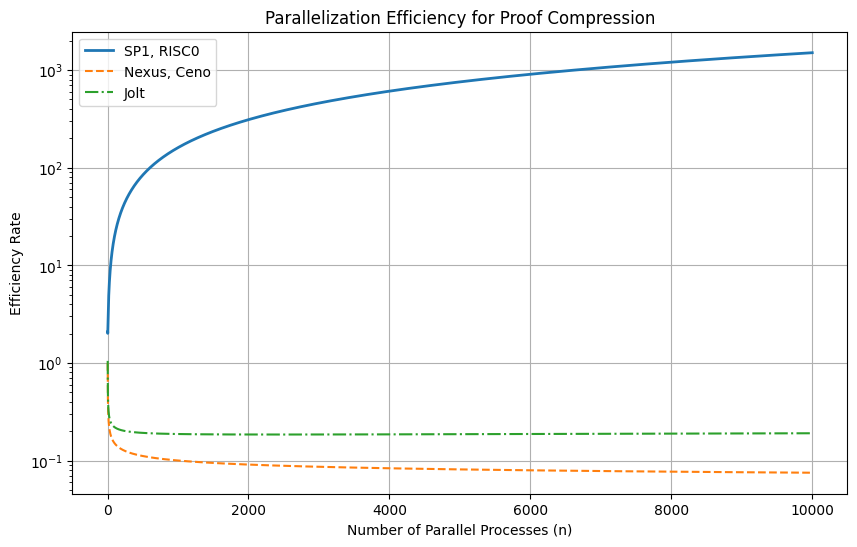

In [100]:
import numpy as np
m = 100_000_000
n_values = np.arange(1, 10000)
log2_n_values = np.log2(n_values)
m_prime = m / n_values

def verify_time_mlogm(m_prime): # SP1, RISC0
    return m_prime * np.log2(m_prime) # O(m'log m')

def verify_time_logm(m_prime): # Nexus, Ceno
    return np.full_like(m_prime, 1000)  # O(log m')

def verify_time_logmloglogm(m_prime): # Jolt
    return np.log2(m_prime) * np.log2(np.log2(m_prime))  # O(log m' loglog m')

total_verify_time_mlogm = log2_n_values * verify_time_mlogm(m_prime)
total_verify_time_logm = log2_n_values * verify_time_logm(m_prime)
total_verify_time_logmloglogm = log2_n_values * verify_time_logmloglogm(m_prime)

ideal_time_mlogm = verify_time_mlogm(m)
efficiency_rate_mlogm = ideal_time_mlogm / total_verify_time_mlogm

ideal_time_logm = verify_time_logm(m)
efficiency_rate_logm = ideal_time_logm / total_verify_time_logm

ideal_time_logmloglogm = verify_time_logmloglogm(m)
efficiency_rate_logmloglogm = ideal_time_logmloglogm / total_verify_time_logmloglogm

plt.figure(figsize=(10, 6))
plt.plot(n_values, efficiency_rate_mlogm, label="SP1, RISC0", linewidth=2)
plt.plot(n_values, efficiency_rate_logm, label="Nexus, Ceno", linestyle='--')
plt.plot(n_values, efficiency_rate_logmloglogm, label="Jolt", linestyle='-.')
plt.xlabel("Number of Parallel Processes (n)")
plt.ylabel("Efficiency Rate")
plt.yscale('log')
plt.title("Parallelization Efficiency for Proof Compression")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
df = pd.DataFrame({
    'n': n_values,
    'SP1, RISC0': efficiency_rate_mlogm,
    'Nexus, Ceno': efficiency_rate_logm,
    'Jolt': efficiency_rate_logmloglogm,
})

df

,n,"SP1, RISC0","Nexus, Ceno",Jolt
0,1,inf,inf,inf
1,2,2.078200,1.000000,1.051395
2,3,2.012835,0.630930,0.683764
3,4,2.162764,0.500000,0.553904
4,5,2.359539,0.430677,0.485439
...,...,...,...,...
9994,9995,1504.397408,0.075262,0.190842
9995,9996,1504.547921,0.075261,0.190842
9996,9997,1504.698435,0.075260,0.190843
9997,9998,1504.848949,0.075259,0.190844


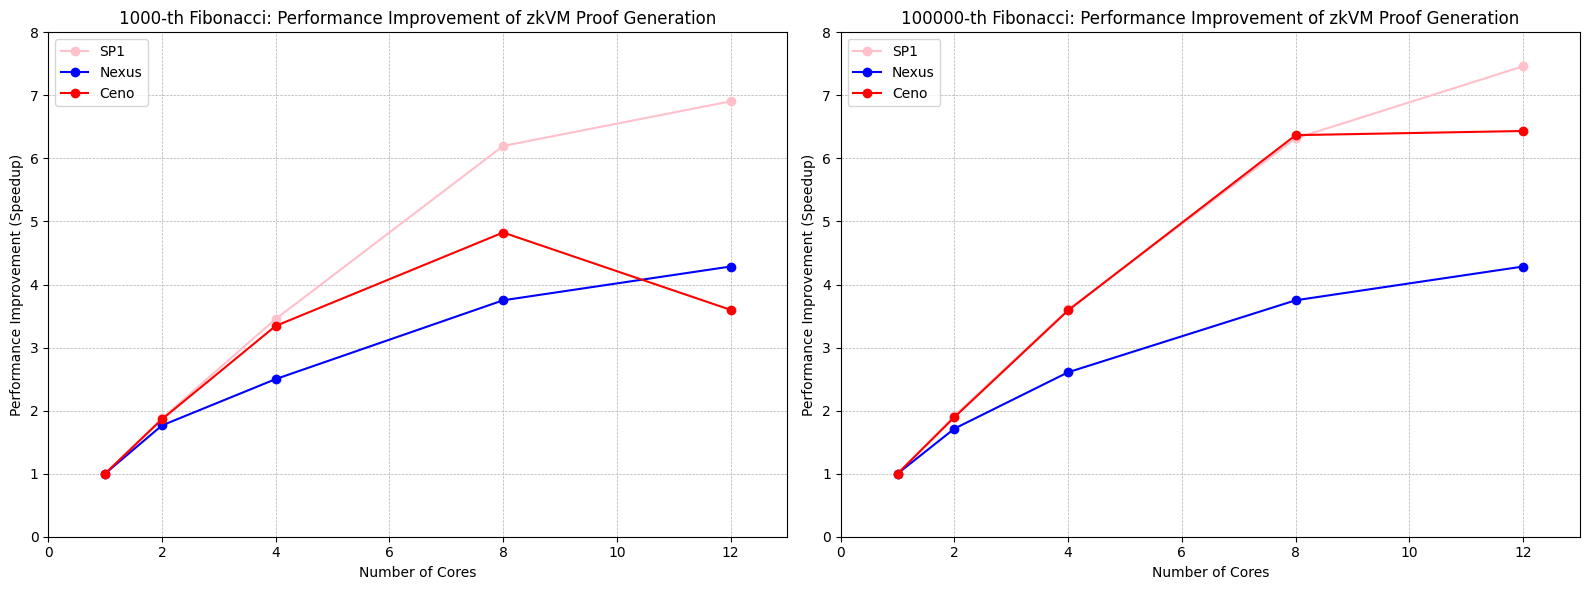

In [40]:
import matplotlib.pyplot as plt

# Data for core counts and proof generation times
cores = [1, 2, 4, 8, 12]
fib1000_sp1_times = [483.4, 257.7, 140, 78, 70]
fib1000_nexus_times = [6, 3.4, 2.4, 1.6, 1.4]
fib1000_ceno_times = [21.23, 11.4, 6.35, 4.4, 5.9]

fib100000_sp1_times = [1140, 594.8, 316.3, 180.4, 152.8]
fib100000_nexus_times = [6,3.5,2.3,1.6,1.4]
fib100000_ceno_times = [124.2,65.5, 34.6, 19.5, 19.3]

# Calculate speedup ratios relative to single core
fib1000_sp1_speedup = [fib1000_sp1_times[0] / time for time in fib1000_sp1_times]
fib1000_nexus_speedup = [fib1000_nexus_times[0] / time for time in fib1000_nexus_times]
fib1000_ceno_speedup = [fib1000_ceno_times[0] / time for time in fib1000_ceno_times]

fib100000_sp1_speedup = [fib100000_sp1_times[0] / time for time in fib100000_sp1_times]
fib100000_nexus_speedup = [fib100000_nexus_times[0] / time for time in fib100000_nexus_times]
fib100000_ceno_speedup = [fib100000_ceno_times[0] / time for time in fib100000_ceno_times]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fibonacci Peak Memory vs Cycles
axes[0].plot(cores, fib1000_sp1_speedup, marker='o', label='SP1', color='pink')
axes[0].plot(cores, fib1000_nexus_speedup, marker='o', label='Nexus', color='blue')
axes[0].plot(cores, fib1000_ceno_speedup, marker='o', label='Ceno', color='red')
axes[0].set_title('1000-th Fibonacci: Performance Improvement of zkVM Proof Generation')
axes[0].set_xlabel('Number of Cores')
axes[0].set_ylabel('Performance Improvement (Speedup)')
axes[0].set_xlim(0, 13)
axes[0].set_ylim(0, 8)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend()

axes[1].plot(cores, fib100000_sp1_speedup, marker='o', label='SP1', color='pink')
axes[1].plot(cores, fib100000_nexus_speedup, marker='o', label='Nexus', color='blue')
axes[1].plot(cores, fib100000_ceno_speedup, marker='o', label='Ceno', color='red')
axes[1].set_title('100000-th Fibonacci: Performance Improvement of zkVM Proof Generation')
axes[1].set_xlabel('Number of Cores')
axes[1].set_ylabel('Performance Improvement (Speedup)')
axes[1].set_xlim(0, 13)
axes[1].set_ylim(0, 8)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()
